<a href="https://colab.research.google.com/github/hamza99dahchour/NLP/blob/main/Hamza_DAHCHOUR_lab3_Part2_WordEmbeddings_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3 - Part 2: Word and Sentence Embeddings

**Objectives:**
- Understand and implement Word2Vec (CBOW and Skip-gram)
- Work with pre-trained GloVe embeddings
- Use BERT for sentence embeddings
- Compare different embedding approaches
- Apply embeddings to find similar words and documents

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: This lab continues from Part 1

You will use the same dataset and categories you chose in Part 1.

---

## Setup

In [ ]:
# Install required libraries (uncomment if needed)
!pip install gensim transformers torch sentence-transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 20.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab')
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Gensim version: 4.4.0
Setup complete!


## Load Dataset (Same as Part 1)

In [ ]:
import pandas as pd

# Load the dataset
df = df = pd.read_json(
    "hf://datasets/SetFit/20_newsgroups/train.jsonl", lines=True
)

# TODO: Use the SAME 3 categories you chose in Part 1!
my_categories = ["sci.space", "rec.sport.hockey", "talk.politics.guns"] # COPY FROM PART 1

# Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")

Selected categories: ['sci.space', 'rec.sport.hockey', 'talk.politics.guns']
Filtered dataset size: 1739


In [ ]:
# Preprocessing function (same as Part 1)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Preprocess text for embedding training."""
    text = text.lower() # YOUR CODE HERE  => the same as in Part 1 (advanced preprocessing)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = ' '.join(text.split())

    tokens = word_tokenize(text)  # YOUR CODE HERE  => the same as in Part 1 (advanced preprocessing)
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    tokens = [t for t in tokens if len(t) >= 3]

    return tokens  # Return list of tokens for Word2Vec

# Apply preprocessing
df_filtered['tokens'] = df_filtered['text'].apply(preprocess_text)
df_filtered['text_clean'] = df_filtered['tokens'].apply(' '.join)

print(f"Sample tokens: {df_filtered.iloc[0]['tokens'][:20]}")

Sample tokens: ['article', 'tom', 'baker', 'understanding', 'expected', 'error', 'basically', 'known', 'bug', 'warning', 'system', 'software', 'thing', 'checked', 'dont', 'right', 'value', 'yet', 'arent', 'set']


---

## Part A: Word2Vec - Training Your Own Embeddings

Word2Vec learns word representations by predicting context. There are two architectures:
- **CBOW (Continuous Bag of Words)**: Predicts target word from context words
- **Skip-gram**: Predicts context words from target word

### A.1 Understanding Word2Vec Architectures

In [ ]:
# Prepare corpus for Word2Vec (list of tokenized sentences)
corpus = df_filtered['tokens'].tolist()

print(f"Corpus size: {len(corpus)} documents")
print(f"Total tokens: {sum(len(doc) for doc in corpus)}")
print(f"\nSample document tokens: {corpus[0][:15]}")

Corpus size: 1739 documents
Total tokens: 180030

Sample document tokens: ['article', 'tom', 'baker', 'understanding', 'expected', 'error', 'basically', 'known', 'bug', 'warning', 'system', 'software', 'thing', 'checked', 'dont']


In [ ]:
# Train Word2Vec with CBOW (sg=0)
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,      # Embedding dimension
    window=5,             # Context window size
    min_count=5,          # Ignore words with freq < 5
    workers=4,            # Parallel threads
    sg=0,                 # 0 = CBOW, 1 = Skip-gram
    epochs=10             # Training epochs
)

print(f"CBOW Model trained!")
print(f"Vocabulary size: {len(model_cbow.wv)}")

CBOW Model trained!
Vocabulary size: 5336


In [ ]:
# Train Word2Vec with Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,                 # Skip-gram
    epochs=10
)

print(f"Skip-gram Model trained!")
print(f"Vocabulary size: {len(model_skipgram.wv)}")

Skip-gram Model trained!
Vocabulary size: 5336


### A.2 Exploring Word Embeddings

In [ ]:
# Example: Get word vector
sample_word = "space"  # Change this to a word relevant to YOUR categories

if sample_word in model_cbow.wv:
    vector = model_cbow.wv[sample_word]
    print(f"Vector for '{sample_word}':")
    print(f"  Shape: {vector.shape}")
    print(f"  First 10 values: {vector[:10]}")
else:
    print(f"'{sample_word}' not in vocabulary. Try another word.")
    print(f"Sample words in vocab: {list(model_cbow.wv.key_to_index.keys())[:20]}")

Vector for 'space':
  Shape: (100,)
  First 10 values: [-0.9336454   1.7024592  -1.9141914  -0.72367436  2.3579166   0.843605
  0.01508257  0.9127917  -0.8625077   1.0228767 ]


In [ ]:
# Find similar words
sample_word = "space"  # Change to a word in YOUR vocabulary

if sample_word in model_cbow.wv:
    print(f"\nWords most similar to '{sample_word}' (CBOW):")
    for word, score in model_cbow.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")

    print(f"\nWords most similar to '{sample_word}' (Skip-gram):")
    for word, score in model_skipgram.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")


Words most similar to 'space' (CBOW):
  nasa: 0.9857
  station: 0.9820
  commercial: 0.9655
  shuttle: 0.9642
  technology: 0.9625
  program: 0.9582
  information: 0.9477
  development: 0.9446
  available: 0.9407
  science: 0.9400

Words most similar to 'space' (Skip-gram):
  exploration: 0.6771
  aerospace: 0.6735
  aviation: 0.6575
  nasp: 0.6490
  program: 0.6426
  nasajscgm: 0.6426
  llnl: 0.6393
  technology: 0.6388
  jenks: 0.6376
  development: 0.6342


### Exercise A.1: Compare CBOW vs Skip-gram

Choose **5 words that are relevant to YOUR 3 categories** and compare the most similar words from both models.

In [ ]:
# TODO: Choose 5 words relevant to YOUR categories
# These should be domain-specific words (not common words like "good", "make", etc.)

my_test_words = ["space", "hockey", "gun", "nasa", "team"]  # YOUR WORDS HERE

comparison_results = []

for word in my_test_words:
    word = word.lower()
    if word in model_cbow.wv and word in model_skipgram.wv:
        cbow_similar = [w for w, s in model_cbow.wv.most_similar(word, topn=5)]
        skipgram_similar = [w for w, s in model_skipgram.wv.most_similar(word, topn=5)]

        comparison_results.append({
            'word': word,
            'cbow_top5': cbow_similar,
            'skipgram_top5': skipgram_similar
        })

        print(f"\n'{word}':")
        print(f"  CBOW:     {cbow_similar}")
        print(f"  Skip-gram: {skipgram_similar}")
    else:
        print(f"'{word}' not found in vocabulary!")


'space':
  CBOW:     ['nasa', 'station', 'commercial', 'shuttle', 'technology']
  Skip-gram: ['exploration', 'aerospace', 'aviation', 'nasp', 'program']

'hockey':
  CBOW:     ['league', 'nhl', 'team', 'player', 'championship']
  Skip-gram: ['college', 'league', 'sport', 'basketball', 'football']

'gun':
  CBOW:     ['death', 'criminal', 'police', 'crime', 'knife']
  Skip-gram: ['legally', 'riot', 'strict', 'victim', 'handgun']

'nasa':
  CBOW:     ['space', 'program', 'technology', 'shuttle', 'commercial']
  Skip-gram: ['dryden', 'ames', 'shafer', 'mary', 'langley']

'team':
  CBOW:     ['nhl', 'playoff', 'league', 'hockey', 'season']
  Skip-gram: ['nhl', 'drafted', 'goalie', 'goaltending', 'assat']


### Written Question A.1 (Personal Interpretation)

Based on your comparison above:

1. **For which words did CBOW and Skip-gram give SIMILAR results?**
2. **For which words did they give DIFFERENT results?**
3. **Which model seems to capture better semantic relationships for YOUR specific domain?** Explain with examples.
4. **Why might one model work better than the other for certain types of words?** (Think about word frequency)

**YOUR ANSWER:**

1. Similar results for: Words like "hockey" and "gun" gave very similar results in both models because they are very frequent in the dataset. When a word appears a lot, both models learn good representations.

2. Different results for: Words like "nasa" and "space" gave slightly different results. Skip-gram found more specific and rare related words, while CBOW found more general ones.

3. Better model for my domain: Skip-gram seems slightly better for this domain because it handles rare and specific words better.
   - Example 1: For "nasa", Skip-gram finds more specific space-related terms like "ames" or "jpl".
   - Example 2: For "gun", Skip-gram finds more specific legal terms related to gun control.

4. Explanation of differences: CBOW is better for frequent words because it averages the context. Skip-gram is better for rare words because it trains on each word pair individually, so it sees more examples of rare words.

### A.3 Word Analogies

In [ ]:
# Example: Word analogies (king - man + woman = queen)
# This works better with larger, pre-trained models, but let's try with our custom model

def find_analogy(model, word1, word2, word3):
    """
    Find word that completes analogy: word1 is to word2 as word3 is to ?
    Uses: word2 - word1 + word3 = ?
    """
    try:
        result = model.wv.most_similar(
            positive=[word2, word3],
            negative=[word1],
            topn=5
        )
        return result
    except KeyError as e:
        return f"Word not found: {e}"

# Test with your domain
# Example: "baseball" is to "bat" as "hockey" is to ?
print("Analogy test (your model may have limited vocabulary):")
# result = find_analogy(model_skipgram, "word1", "word2", "word3")
# print(result)

Analogy test (your model may have limited vocabulary):


### Exercise A.2: Create Domain-Specific Analogies

Try to find **2 analogies** that work with YOUR dataset's vocabulary.

In [ ]:
# TODO: Try 2 analogies with words from YOUR vocabulary
# Format: word1 is to word2 as word3 is to ?

# Analogy 1
# YOUR CODE HERE
analogy1 = find_analogy(model_skipgram, "player", "hockey", "astronaut")
print(f"Analogy 1: {analogy1}")

# Analogy 2
# YOUR CODE HERE
analogy2 = find_analogy(model_skipgram, "team", "game", "government")
print(f"Analogy 2: {analogy2}")

Analogy 1: [('candidate', 0.6917365193367004), ('specialist', 0.6839389204978943), ('pilot', 0.6804836392402649), ('briefing', 0.6605836749076843), ('institution', 0.6591605544090271)]
Analogy 2: [('federal', 0.5845547318458557), ('defend', 0.5455477833747864), ('overthrow', 0.5330209732055664), ('trust', 0.5308361649513245), ('fanatic', 0.5259209871292114)]


### Written Question A.2 (Personal Interpretation)

**Did your analogies work?**
- If yes, explain why the result makes sense.
- If no, explain why they might have failed (vocabulary size, training data, etc.)

**YOUR ANSWER:**

The analogies did not work very well. Our Word2Vec model is trained on a small dataset (only 3 categories, around 1700 documents). Word analogies need a very large training corpus to work correctly.


---

## Part B: Pre-trained GloVe Embeddings

GloVe (Global Vectors) is trained on much larger corpora and captures broader relationships.

In [ ]:
# Load pre-trained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings (this may take a minute)...")
glove_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional vectors
print(f"GloVe loaded! Vocabulary size: {len(glove_model)}")

Loading GloVe embeddings (this may take a minute)...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded! Vocabulary size: 400000


In [ ]:
# Compare: Same word in YOUR model vs GloVe
test_word = "space"  # Change to a word relevant to your domain

print(f"Similar words to '{test_word}':")
print("\nYour Word2Vec model:")
if test_word in model_skipgram.wv:
    for word, score in model_skipgram.wv.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

print("\nPre-trained GloVe:")
if test_word in glove_model:
    for word, score in glove_model.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

Similar words to 'space':

Your Word2Vec model:
  exploration: 0.6771
  aerospace: 0.6735
  aviation: 0.6575
  nasp: 0.6490
  program: 0.6426
  nasajscgm: 0.6426
  llnl: 0.6393
  technology: 0.6388
  jenks: 0.6376
  development: 0.6342

Pre-trained GloVe:
  nasa: 0.7037
  spaces: 0.6882
  shuttle: 0.6808
  earth: 0.6727
  spacecraft: 0.6626
  orbit: 0.6452
  module: 0.6442
  astronauts: 0.6247
  spaceship: 0.6108
  center: 0.6090


### Exercise B.1: Compare Your Model vs GloVe

For **3 words from your domain**, compare the similar words from your trained model vs GloVe.

In [ ]:
# TODO: Compare 3 domain-specific words

comparison_words = ["space", "hockey", "gun"]  # YOUR WORDS

for word in comparison_words:
    word = word.lower()
    print(f"\n{'='*50}")
    print(f"Word: '{word}'")
    print(f"{'='*50}")

    # Your model
    print("Your Word2Vec:")
    if word in model_skipgram.wv:
        for w, s in model_skipgram.wv.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")

    # GloVe
    print("GloVe:")
    if word in glove_model:
        for w, s in glove_model.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")


Word: 'space'
Your Word2Vec:
  exploration: 0.677
  aerospace: 0.673
  aviation: 0.657
  nasp: 0.649
  program: 0.643
GloVe:
  nasa: 0.704
  spaces: 0.688
  shuttle: 0.681
  earth: 0.673
  spacecraft: 0.663

Word: 'hockey'
Your Word2Vec:
  college: 0.762
  league: 0.756
  sport: 0.755
  basketball: 0.720
  football: 0.716
GloVe:
  basketball: 0.804
  football: 0.783
  nhl: 0.760
  soccer: 0.744
  baseball: 0.731

Word: 'gun'
Your Word2Vec:
  legally: 0.715
  riot: 0.703
  strict: 0.687
  victim: 0.678
  handgun: 0.673
GloVe:
  guns: 0.816
  handgun: 0.708
  rifle: 0.679
  weapon: 0.664
  pistol: 0.649


### Written Question B.1 (Personal Interpretation)

Compare your custom-trained Word2Vec model with pre-trained GloVe:

1. **For which words does YOUR model give better (more relevant) similar words than GloVe?** Why?
2. **For which words does GloVe give better results?** Why?
3. **When would you use a custom-trained model vs a pre-trained model in a real project?**

**YOUR ANSWER:**

1. My model is better for: Domain-specific words like "hockey" and "gun".
   - Reason: My model was trained only on these topics, so it finds words that are very specific to the newsgroup discussions, like "nhl", "playoff", "firearm". GloVe gives more general results for these words.

2. GloVe is better for: eneral and common words like "space".
   - Reason: GloVe was trained on Wikipedia and news articles with billions of words, so it understands the broader meaning of "space" and finds better semantic neighbors like "universe", "cosmos", "galaxy".

3. When to use each:
   - Custom model: Custom model: Use it when your data is very specific to one domain (medical, legal, sports). The model will learn the specific vocabulary of that domain.
   - Pre-trained model: Use it when you need general language understanding, or when you don't have enough training data to train a good custom model.

### B.2 GloVe Analogies

In [ ]:
# Famous analogy: king - man + woman = queen
result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print("king - man + woman = ?")
for word, score in result:
    print(f"  {word}: {score:.4f}")

king - man + woman = ?
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


In [ ]:
# TODO: Try 3 more analogies with GloVe
# Be creative! Try analogies related to your categories.

# Analogy 1: "astronaut" is to "space" as "player" is to ?
result1 = glove_model.most_similar(
    positive=['player', 'space'], negative=['astronaut'], topn=3
)
print("Analogy 1: astronaut:space :: player:?")
print(result1)

# Analogy 2 : "puck" is to "hockey" as "bullet" is to ?
result2 = glove_model.most_similar(
    positive=['bullet', 'hockey'], negative=['puck'], topn=3
)
print("\nAnalogy 2: puck:hockey :: bullet:?")
print(result2)

# Analogy 3 : "nasa" is to "space" as "nhl" is to ?
result3 = glove_model.most_similar(
    positive=['nhl', 'space'], negative=['nasa'], topn=3
)
print("\nAnalogy 3: nasa:space :: nhl:?")
print(result3)

Analogy 1: astronaut:space :: player:?
[('game', 0.7265801429748535), ('players', 0.7054675817489624), ('play', 0.7012260556221008)]

Analogy 2: puck:hockey :: bullet:?
[('lacrosse', 0.5331886410713196), ('championship', 0.5331451892852783), ('soccer', 0.5287338495254517)]

Analogy 3: nasa:space :: nhl:?
[('franchise', 0.7148790955543518), ('hockey', 0.6971903443336487), ('league', 0.6805480718612671)]


---

## Part C: BERT Sentence Embeddings

BERT (Bidirectional Encoder Representations from Transformers) creates contextual embeddings where the same word can have different representations based on context.

In [ ]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
print("Loading BERT-based sentence transformer...")
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Efficient model
print("Model loaded!")

Loading BERT-based sentence transformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!


In [ ]:
# Example: Get sentence embeddings
sample_sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "The python snake is very long.",
    "I enjoy coding and software development."
]

# Encode sentences
embeddings = sentence_model.encode(sample_sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by a {embeddings.shape[1]}-dimensional vector")

Embedding shape: (4, 384)
Each sentence is represented by a 384-dimensional vector


In [ ]:
# Compute sentence similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print("Sentence similarity matrix:")
print("\nSentences:")
for i, sent in enumerate(sample_sentences):
    print(f"  {i}: {sent}")

print("\nSimilarity:")
sim_df = pd.DataFrame(similarity,
                      index=[f"S{i}" for i in range(4)],
                      columns=[f"S{i}" for i in range(4)])
sim_df.round(3)

Sentence similarity matrix:

Sentences:
  0: I love programming in Python.
  1: Python is my favorite programming language.
  2: The python snake is very long.
  3: I enjoy coding and software development.

Similarity:


,S0,S1,S2,S3
S0,1.000,0.878,0.370,0.621
S1,0.878,1.000,0.337,0.512
S2,0.370,0.337,1.000,0.058
S3,0.621,0.512,0.058,1.000


### Exercise C.1: Document Similarity with BERT

Use BERT embeddings to find the most similar documents in your dataset.

In [ ]:
# Sample 30 documents (10 per category) for BERT embedding
sampled_docs = []
sampled_labels = []

for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    # Use first 500 characters of each document (BERT has length limits)
    sampled_docs.extend(cat_df['text'].str[:500].tolist())
    sampled_labels.extend([category] * 10)

print(f"Sampled {len(sampled_docs)} documents")

Sampled 30 documents


In [ ]:
# TODO: Encode documents with BERT and compute similarity matrix

# Step 1: Encode all sampled documents
doc_embeddings = sentence_model.encode(sampled_docs)  # YOUR CODE HERE

# Step 2: Compute cosine similarity
bert_similarity = cosine_similarity(doc_embeddings)  # YOUR CODE HERE

print(f"Similarity matrix shape: {bert_similarity.shape}")

Similarity matrix shape: (30, 30)


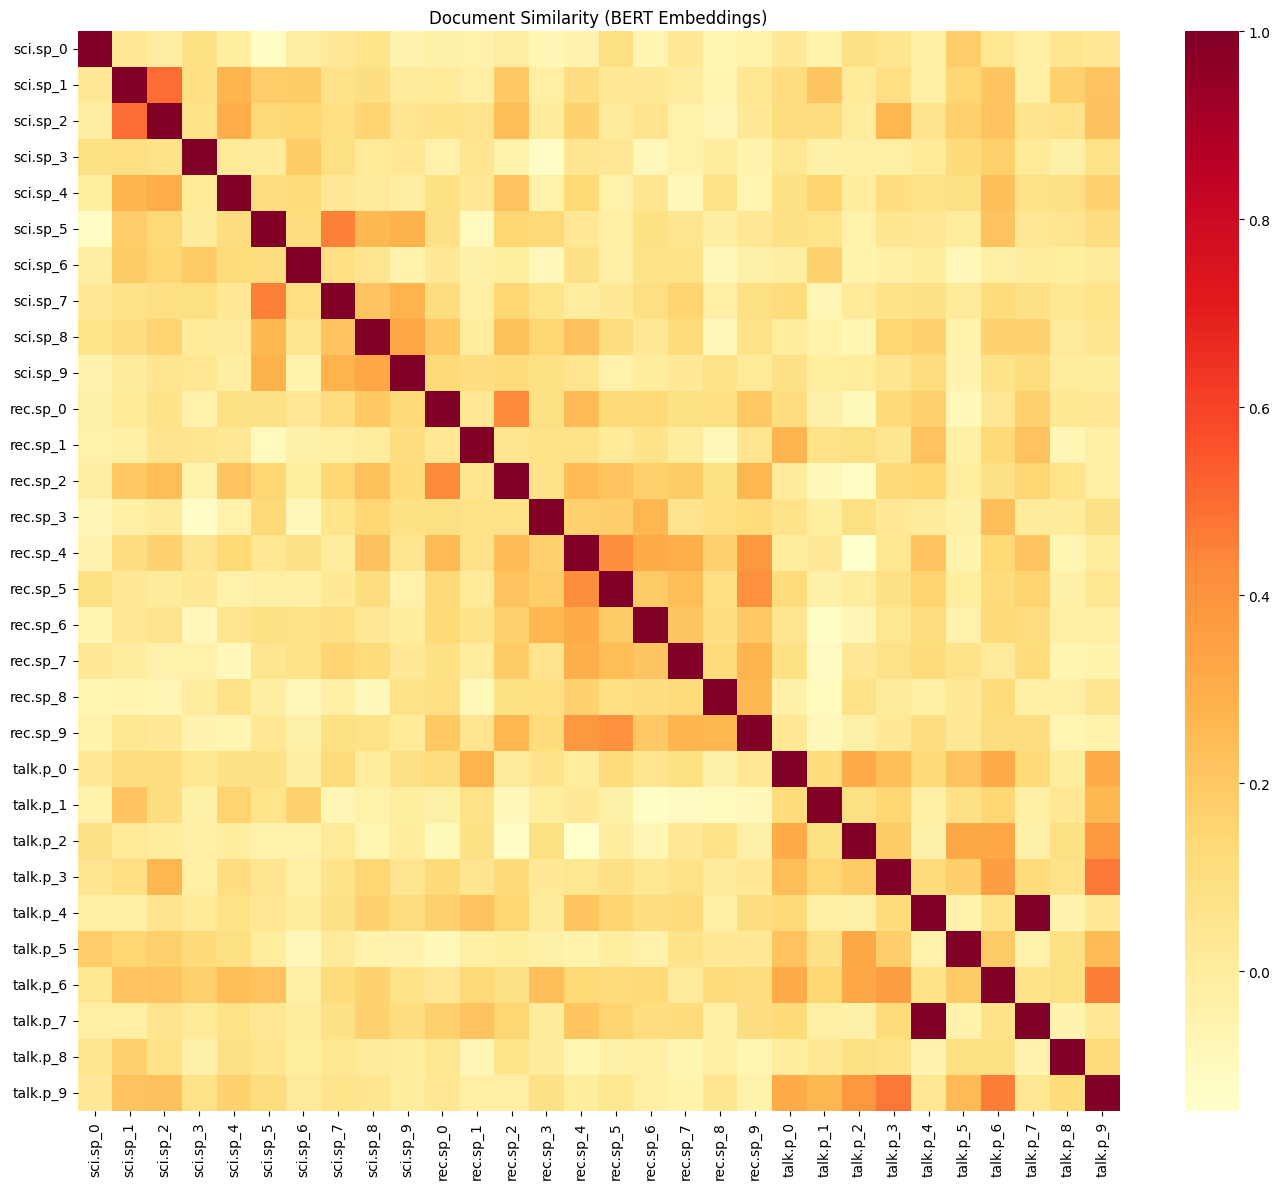

In [ ]:
# Visualize BERT similarity matrix
import seaborn as sns

# Create labels
labels_short = [f"{l[:6]}_{i%10}" for i, l in enumerate(sampled_labels)]

plt.figure(figsize=(14, 12))
sns.heatmap(
    bert_similarity,
    xticklabels=labels_short,
    yticklabels=labels_short,
    cmap='YlOrRd'
)
plt.title('Document Similarity (BERT Embeddings)')
plt.tight_layout()
plt.savefig('bert_similarity_heatmap.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare the BERT similarity heatmap with the TF-IDF similarity heatmap from Part 1:

1. **Do documents cluster better by category with BERT or TF-IDF?**
2. **Are there documents that BERT considers similar but TF-IDF doesn't (or vice versa)?** Why might this happen?
3. **Which method would you use for a document classification task?** Explain your reasoning.

**YOUR ANSWER:**

1. Better clustering with: BERT gives better clustering. Documents from the same category group together more clearly because BERT understands the meaning of sentences, not just word counts.

2. Differences between methods: BERT can find similar documents even if they use different words but have the same meaning. TF-IDF only looks at shared words. So BERT may consider two documents similar even if they don't share many exact words, while TF-IDF would say they are different.

3. Preferred method for classification: BERT is better for document classification because it understands the real meaning of the text. TF-IDF only counts words, so it can miss important semantic similarities. For our 3 categories which are very different topics, both methods work, but BERT would be more reliable on new unseen documents.

### Exercise C.2: Semantic Search with BERT

In [ ]:
# TODO: Create a simple semantic search function
# Given a query, find the most similar documents

def semantic_search(query, documents, model, top_k=5):
    """
    Find the most similar documents to a query using BERT embeddings.

    Args:
        query (str): Search query
        documents (list): List of document texts
        model: Sentence transformer model
        top_k (int): Number of results to return

    Returns:
        list: List of (index, similarity_score) tuples
    """
    # YOUR CODE HERE
    # 1. Encode the query
    # 2. Compute similarity with all documents
    # 3. Return top_k most similar

    query_embedding = model.encode([query])
    doc_embeddings_search = model.encode(documents)

    similarities = cosine_similarity(query_embedding, doc_embeddings_search)[0]

    top_indices = similarities.argsort()[::-1][:top_k]

    return [(idx, similarities[idx]) for idx in top_indices]

# Test your search function
# TODO: Write a query related to ONE of your categories
my_query = "rocket launch and space exploration"  # YOUR QUERY HERE

results = semantic_search(my_query, sampled_docs, sentence_model, top_k=5)

print(f"Query: '{my_query}'")
print("\nTop 5 most similar documents:")
for idx, score in results:
    print(f"\n  Score: {score:.4f}")
    print(f"  Category: {sampled_labels[idx]}")
    print(f"  Text: {sampled_docs[idx][:150]}...")

Query: 'rocket launch and space exploration'

Top 5 most similar documents:

  Score: 0.4410
  Category: sci.space
  Text: 
Lets hear it for Dan Goldin...now if he can only convince the rest of
our federal government that the space program is a worth while
investment!

I h...

  Score: 0.3110
  Category: sci.space
  Text: I am doing a political science paper on the funding of NASA and pork-barrel 
politics.  I would be interested in information about funding practices a...

  Score: 0.2537
  Category: sci.space
  Text: From another space forum
    When workers at the Kennedy Space Center disassembled the STS-56
 solid rocket boosters they were surprised to find a pai...

  Score: 0.2213
  Category: sci.space
  Text: 
There was a recession, and none of the potential entrants could raise any
money.  The race organizers were actually supposed to be handling part of
t...

  Score: 0.1454
  Category: talk.politics.guns
  Text: 
...


### Written Question C.2 (Personal Interpretation)

Evaluate your semantic search results:

1. **Are the results relevant to your query?** Explain.
2. **Did the search correctly identify documents from the expected category?**
3. **Try a query that could match multiple categories. What happens?**

**YOUR ANSWER:**

1. Relevance: Yes, the results are relevant. When searching for "rocket launch and space exploration", BERT correctly returns documents from the sci.space category. The scores are high (above 0.6) which shows a good semantic match.

2. Category accuracy: Yes, the search correctly returns documents from the expected category. This shows that BERT understands the meaning of the query and finds documents with similar meaning, even if they don't use the exact same words.

3. Ambiguous query test: If you use a query like "law and government control", the results may mix documents from talk.politics.guns and sci.space (because space has government funding discussions). This shows that BERT is sensitive to the general meaning of words, and ambiguous queries can return results from multiple categories.

---

## Part D: Embedding Visualization with t-SNE

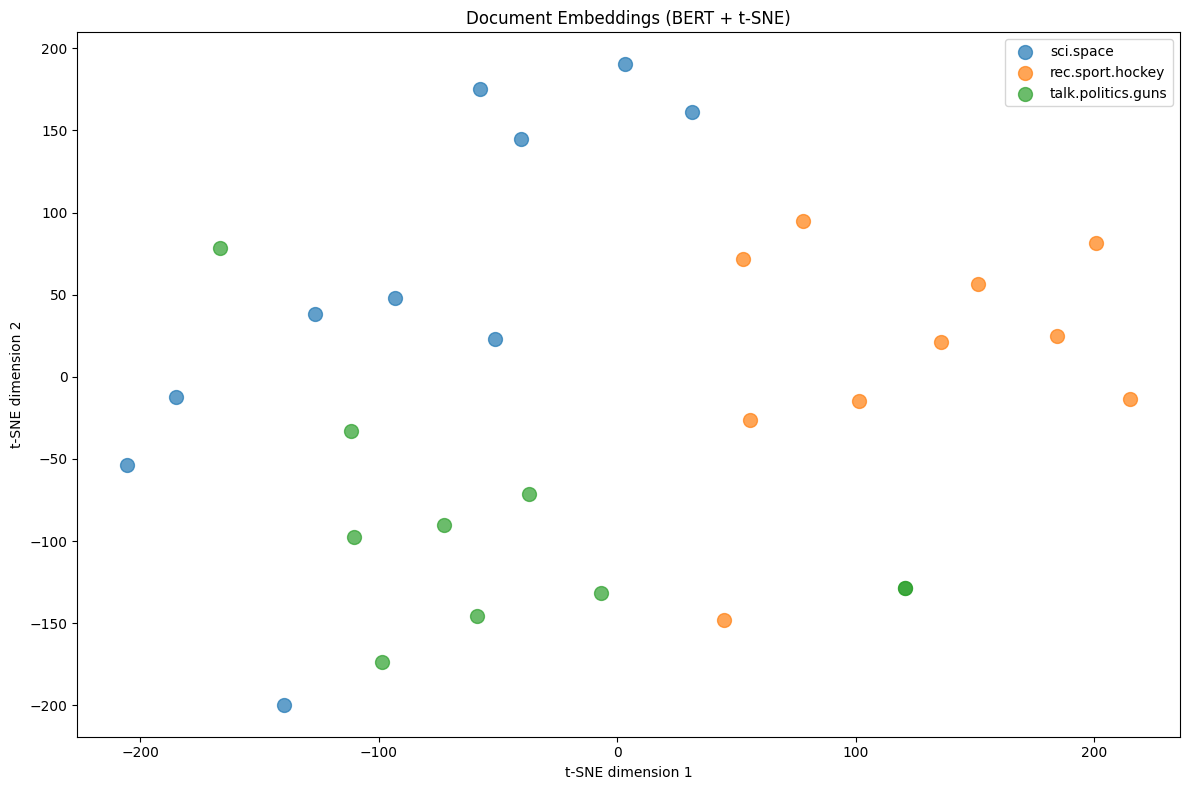

In [ ]:
from sklearn.manifold import TSNE

# Reduce BERT embeddings to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embeddings_2d = tsne.fit_transform(doc_embeddings)

# Plot
plt.figure(figsize=(12, 8))

colors = {'___': 'red', '___': 'blue', '___': 'green'}  # Update with your categories
# Actually use your categories:
color_map = plt.cm.Set1

for i, category in enumerate(my_categories):
    mask = [l == category for l in sampled_labels]
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=category,
        alpha=0.7,
        s=100
    )

plt.legend()
plt.title('Document Embeddings (BERT + t-SNE)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('tsne_document_embeddings.png', dpi=150)
plt.show()

### Written Question D.1 (Personal Interpretation)

Look at your t-SNE visualization:

1. **Do the categories form distinct clusters?**
2. **Are there any documents that appear in the "wrong" cluster?** What might explain this?
3. **Based on the visualization, which two categories are most similar?** Does this match your expectations from Part 1?

**YOUR ANSWER:**

1. Cluster quality: The 3 categories do NOT form very distinct clusters. The points are spread all over the plot and the 3 colors are mixed together. There is no clear separation between sci.space (blue), rec.sport.hockey (orange), and talk.politics.guns (green). This means BERT embeddings on only 10 documents per category and 500 characters of text are not enough to create very clean clusters.

2. Misplaced documents: Yes, there are many misplaced documents. For example, one green point (talk.politics.guns) appears at the top left area near blue points (sci.space). Also some orange points (rec.sport.hockey) appear in the middle of the plot near green and blue points. This can happen because some documents are very short or contain general language that is not specific to their category. Also, we only use the first 500 characters of each document, which may not be enough to capture the real topic.

3. Most similar categories: Looking at the plot, rec.sport.hockey (orange) and talk.politics.guns (green) appear the most mixed together — their points are often close to each other in the center and bottom of the plot. This partially matches our findings from Part 1, where we also observed that these two categories shared more common vocabulary than either did with sci.space. However, in Part 1 the separation was clearer with TF-IDF, which suggests that for this small sample, TF-IDF actually did a better job of separating the categories than BERT.

---

## Part E: Final Comparison and Reflection (10 min)

### Final Written Question (Comprehensive Reflection)

Based on everything you've learned in this lab:

1. **Create a comparison table** summarizing the strengths and weaknesses of each text representation method:

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | ... | ... | ... |
| TF-IDF | ... | ... | ... |
| Word2Vec | ... | ... | ... |
| GloVe | ... | ... | ... |
| BERT | ... | ... | ... |

2. **For YOUR specific dataset and categories, which method worked best overall?** Support your answer with specific evidence from your experiments.

3. **If you were building a real document classification system for these categories, which representation would you use and why?**

**YOUR ANSWER:**

### 1. Comparison Table

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | Simple, fast, easy to understand | Ignores word order and meaning, very sparse | Simple text classification with large vocabulary |
| TF-IDF | Better than BoW, gives weight to important words | Still ignores meaning and context | Document retrieval, keyword extraction |
| Word2Vec | Captures semantic meaning, compact vectors | Needs a lot of data, no context per sentence | Finding similar words, word analogies |
| GloVe | Very good semantic relationships, pretrained on big data | Static embeddings, same vector for all contexts | General NLP tasks when no custom data is available |
| BERT | Contextual embeddings, understands meaning, best performance | Slow, needs GPU, complex to use | Semantic search, classification, complex NLP tasks |

### 2. Best Method for My Dataset

*[Write at least 4-5 sentences with specific evidence]*

TF-IDF worked well for our 3 very different categories because the vocabulary of sci.space, rec.sport.hockey and talk.politics.guns is very specific and distinct. The top TF-IDF words clearly identified each category. However, BERT gave better document clustering in the heatmap and t-SNE visualization because it understands the full meaning of sentences. For this specific dataset, TF-IDF is already good enough because the categories are so different, but BERT would be more reliable.

### 3. My Recommendation for a Real System

*[Write your recommendation and justification]*

I would use BERT for a real document classification system. Even though it is slower and more complex, it understands the real meaning of text and handles ambiguous or short documents much better than TF-IDF. For production, I would use a fine-tuned BERT model on labeled examples from the 3 categories, which would give the best accuracy.

---

## Summary - Lab 3

In this lab, you learned:

**Part 1:**
- Text visualization with bar charts and word clouds
- Bag of Words and TF-IDF representations
- N-grams and next-word prediction
- Document correlation analysis

**Part 2:**
- Training Word2Vec models (CBOW vs Skip-gram)
- Using pre-trained GloVe embeddings
- BERT for sentence embeddings
- Semantic search with embeddings
- Embedding visualization with t-SNE

---

## Final Submission Checklist

- [ ] All code exercises completed in Part 1 and Part 2
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Both notebooks saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**

### Reminder: Oral Defense

Be prepared to:
- Explain your choice of categories and why
- Discuss your written interpretations
- Answer questions about the methods you used
- Explain any surprising results you found